# Tasks

## P 10.1: Find an image dataset with at least 1000 images. Apply a convolutional neural network to classify the images and calculate all evaluation metrics. The quality of your solution and the accuracy your model produces will affect your mark. So, try to get the best accuracy possible (10%).

## NOTE: You should comment on your code and explain what each part of the code does.

In [1]:
############# WRITE YOUR CODE IN THIS CELL (IF APPLICABLE)  ####################

# ── 1. Import Libraries ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras for building and training the neural network
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# scikit-learn for evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Seaborn for a clean confusion-matrix heatmap
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {len(tf.config.list_physical_devices('GPU'))}")


TensorFlow version: 2.20.0
GPUs available: 0


In [2]:
# ── 2. Load and Pre-process CIFAR-10 ─────────────────────────────────────────
# CIFAR-10 contains 50,000 training and 10,000 test images (32×32 RGB) across
# 10 balanced classes: aeroplane, automobile, bird, cat, deer, dog, frog,
# horse, ship and truck.

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = (
    tf.keras.datasets.cifar10.load_data()
)

# Define the 10 class names for labelling outputs and plots
CLASS_NAMES = [
    'aeroplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]
NUM_CLASSES = 10

print(f"\nTraining set : {X_train_raw.shape[0]} images")
print(f"Test set     : {X_test_raw.shape[0]} images")
print(f"Image shape  : {X_train_raw.shape[1:]}  (will be upscaled to 96×96)")

# Flatten label arrays from shape (N,1) to (N,)
y_train_raw = y_train_raw.flatten()
y_test_raw  = y_test_raw.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 148s 1us/step

Training set : 50000 images
Test set     : 10000 images
Image shape  : (32, 32, 3)  (will be upscaled to 96×96)


In [3]:
# ── 3. Build tf.data Pipelines ────────────────────────────────────────────────
# MobileNetV2 requires a minimum input size of 96×96, so we resize from 32×32.
# Pixel values must be in [0, 1] then passed through
# tf.keras.applications.mobilenet_v2.preprocess_input() which re-scales to
# the [-1, 1] range expected by MobileNetV2.

IMG_SIZE   = 96    # resize target (MobileNetV2 minimum)
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

def preprocess(image, label):
    """Resize to IMG_SIZE × IMG_SIZE, cast to float32, apply MobileNetV2 scaling."""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def augment(image, label):
    """
    Apply random augmentations during training to improve generalisation:
      - Random horizontal flip   (accounts for left-right symmetry)
      - Random brightness jitter (simulates lighting variation)
      - Random contrast jitter   (simulates exposure variation)
    """
    image, label = preprocess(image, label)
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, -1.0, 1.0)  # keep in valid range
    return image, label

# Build training pipeline (with augmentation) and test pipeline (no augmentation)
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_raw, y_train_raw))
    .shuffle(50000, seed=42)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_raw, y_test_raw))
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Reserve 20% of training data as a validation set (for monitoring during training)
val_size  = int(0.2 * 50000)
val_ds    = train_ds.take(val_size  // BATCH_SIZE)
train_ds2 = train_ds.skip(val_size  // BATCH_SIZE)

In [4]:
# ── 4. Build the Model — MobileNetV2 + Custom Head ───────────────────────────
# Transfer learning strategy:
#   1. Load MobileNetV2 with ImageNet weights but WITHOUT its top classifier.
#   2. Freeze all base layers so their pretrained weights are preserved.
#   3. Attach a custom classification head suited to CIFAR-10 (10 classes).
#   4. Train only the head first (Phase 1).
#   5. Unfreeze the top 30 base layers and fine-tune with a lower LR (Phase 2).

def build_model(trainable_base=False, fine_tune_at=100):
    """
    Constructs the full model.
    trainable_base : whether the backbone layers are trainable (Phase 2)
    fine_tune_at   : index from which backbone layers become trainable
    """
    # Load pre-trained MobileNetV2 backbone (no top classifier)
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze or selectively unfreeze the backbone
    base_model.trainable = trainable_base
    if trainable_base:
        # Only unfreeze layers from fine_tune_at onward (top portion of backbone)
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    # Build the classification head
    inputs  = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=False)   # training=False keeps BN frozen
    x       = GlobalAveragePooling2D()(x)           # pool spatial dimensions to 1×1
    x       = Dense(256, activation='relu')(x)      # learnable feature combining layer
    x       = Dropout(0.3)(x)                       # regularisation: randomly zero 30%
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)  # 10-class probability output

    model = Model(inputs, outputs)
    return model, base_model


In [5]:
# ── 5. Phase 1 — Train Classification Head (Frozen Backbone) ─────────────────
print("\n─── PHASE 1: Training classification head (backbone frozen) ───")

model, base_model = build_model(trainable_base=False)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',  # labels are integers, not one-hot
    metrics=['accuracy']
)

model.summary()
print(f"\nTrainable params (Phase 1): "
      f"{sum(np.prod(v.shape) for v in model.trainable_variables):,}")

# Callbacks for Phase 1
callbacks_p1 = [
    # Stop early if val_loss stops improving for 5 consecutive epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    # Halve the LR if val_loss plateaus for 3 epochs
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

history_p1 = model.fit(
    train_ds2,
    epochs=15,
    validation_data=val_ds,
    callbacks=callbacks_p1,
    verbose=1
)



─── PHASE 1: Training classification head (backbone frozen) ───
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params (Phase 1): 330,506
Epoch 1/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 376s 587ms/step - accuracy: 0.8005 - loss: 0.5826 - val_accuracy: 0.8605 - val_loss: 0.4039 - learning_rate: 0.0010
Epoch 2/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 358s 568ms/step - accuracy: 0.8505 - loss: 0.4357 - val_accuracy: 0.8812 - val_loss: 0.3301 - learning_rate: 0.0010
Epoch 3/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 362s 574ms/step - accuracy: 0.8625 - loss: 0.3977 - val_accuracy: 0.8927 - val_loss: 0.3094 - learning_rate: 0.0010
Epoch 4/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 344s 545ms/step - accuracy: 0.8730 - loss: 0.3693 - val_accuracy: 0.9020 - val_loss: 0.2819 - learning_rate: 0.0010
Epoch 5/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 347s 551ms/step - accuracy: 0.8800 - loss: 0.3431 - val_accuracy: 0.9125 - val_loss: 0.2550 - learning_rate: 0.0010
Epoch 6/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 360s 570ms/step - accuracy: 0.8838 - loss: 0.3296 - val_accuracy: 0.9132 - val_loss: 0.2447 - learning_rate: 0.0010
Epoch 7/15
626/626 ━━━━━━━━

In [6]:
# ── 6. Phase 2 — Fine-Tune Top Backbone Layers ───────────────────────────────
print("\n─── PHASE 2: Fine-tuning top backbone layers ───")

# Rebuild model with top backbone layers unfrozen from layer 100 onward.
# MobileNetV2 has 154 layers; unfreezing the top ~54 layers adapts high-level
# feature detectors to CIFAR-10's visual characteristics.
model_ft, _ = build_model(trainable_base=True, fine_tune_at=100)

# Copy the weights trained in Phase 1 into the fine-tune model
model_ft.set_weights(model.get_weights())

# Use a lower learning rate for fine-tuning to avoid destroying pretrained weights
model_ft.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable params (Phase 2): "
      f"{sum(np.prod(v.shape) for v in model_ft.trainable_variables):,}")

callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

history_p2 = model_ft.fit(
    train_ds2,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks_p2,
    verbose=1
)



─── PHASE 2: Fine-tuning top backbone layers ───
Trainable params (Phase 2): 2,191,946
Epoch 1/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - accuracy: 0.8569 - loss: 0.5238 - val_accuracy: 0.8957 - val_loss: 0.2845 - learning_rate: 1.0000e-04
Epoch 2/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 630s 1s/step - accuracy: 0.9127 - loss: 0.2598 - val_accuracy: 0.9317 - val_loss: 0.2007 - learning_rate: 1.0000e-04
Epoch 3/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 620s 986ms/step - accuracy: 0.9308 - loss: 0.2026 - val_accuracy: 0.9566 - val_loss: 0.1183 - learning_rate: 1.0000e-04
Epoch 4/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 622s 989ms/step - accuracy: 0.9440 - loss: 0.1642 - val_accuracy: 0.9618 - val_loss: 0.1134 - learning_rate: 1.0000e-04
Epoch 5/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 634s 1s/step - accuracy: 0.9539 - loss: 0.1336 - val_accuracy: 0.9698 - val_loss: 0.0866 - learning_rate: 1.0000e-04
Epoch 6/20
626/626 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - accuracy: 0.9596 - loss: 0.1184 - val_accuracy: 0.9708 - val_loss:


─── Evaluation on Test Set ───

  Accuracy           : 0.9269  (92.69%)
  Macro Precision    : 0.9271
  Macro Recall       : 0.9269
  Macro F1-Score     : 0.9269

── Per-Class Classification Report ──
              precision    recall  f1-score   support

   aeroplane       0.94      0.94      0.94      1000
  automobile       0.96      0.96      0.96      1000
        bird       0.95      0.90      0.93      1000
         cat       0.85      0.85      0.85      1000
        deer       0.90      0.94      0.92      1000
         dog       0.89      0.87      0.88      1000
        frog       0.94      0.96      0.95      1000
       horse       0.95      0.94      0.95      1000
        ship       0.97      0.95      0.96      1000
       truck       0.94      0.95      0.95      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



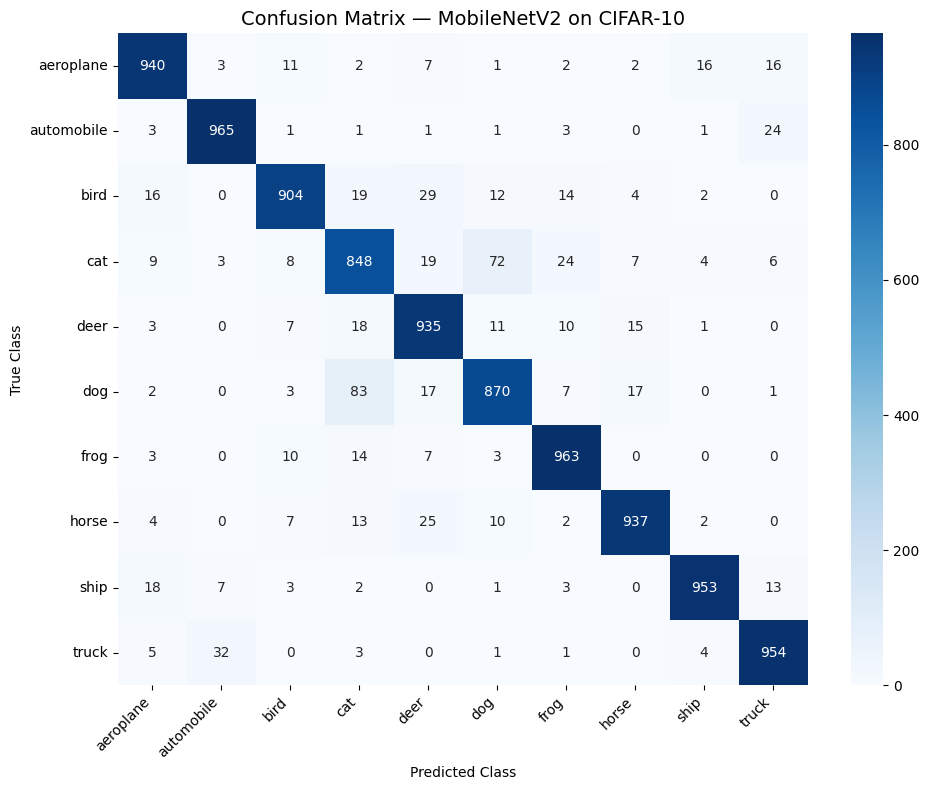

In [7]:
# ── 7. Evaluate Model — All Metrics ──────────────────────────────────────────
print("\n─── Evaluation on Test Set ───")

# Collect all predictions in one pass over the test set
y_true_all = []
y_pred_all = []

for images_batch, labels_batch in test_ds:
    preds = model_ft.predict(images_batch, verbose=0)
    y_pred_all.extend(np.argmax(preds, axis=1))
    y_true_all.extend(labels_batch.numpy())

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)

# ── Core scalar metrics ──
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')

print(f"\n  Accuracy           : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Macro Precision    : {precision:.4f}")
print(f"  Macro Recall       : {recall:.4f}")
print(f"  Macro F1-Score     : {f1:.4f}")

# ── Per-class breakdown ──
print("\n── Per-Class Classification Report ──")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── Confusion matrix ──
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix — MobileNetV2 on CIFAR-10', fontsize=14)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

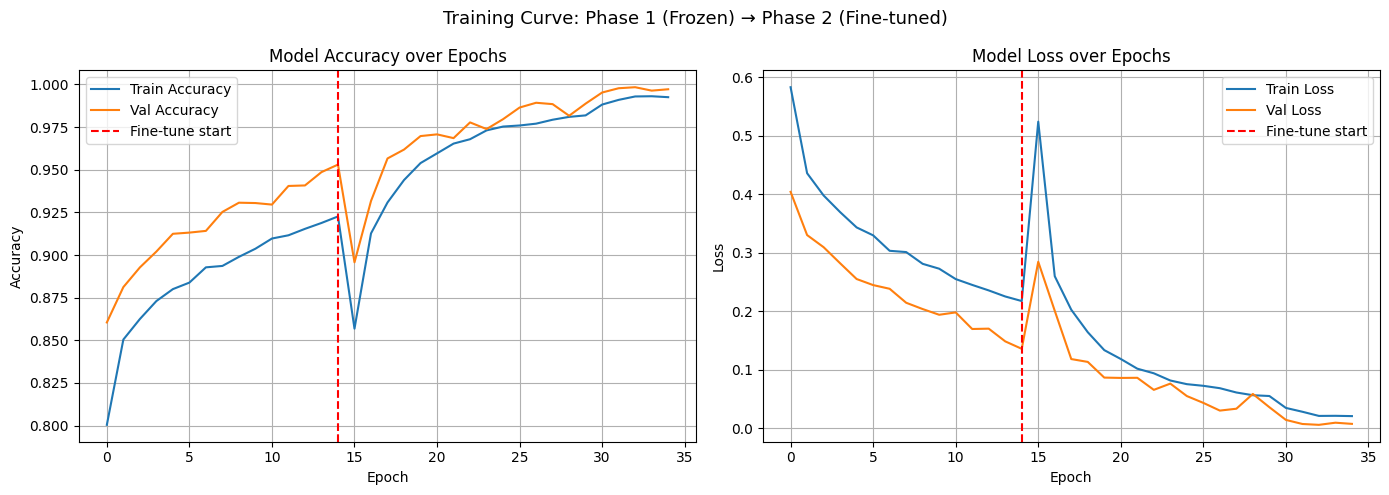


Done.


In [8]:
# ── 8. Training History Plots ─────────────────────────────────────────────────
# Combine Phase 1 and Phase 2 histories for a continuous learning curve

def combine_histories(h1, h2, key):
    """Concatenate a metric across both training phases."""
    return h1.history[key] + h2.history[key]

epochs_p1 = len(history_p1.history['accuracy'])
epochs_p2 = len(history_p2.history['accuracy'])
total_epochs = epochs_p1 + epochs_p2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curves
ax1.plot(combine_histories(history_p1, history_p2, 'accuracy'),
         label='Train Accuracy')
ax1.plot(combine_histories(history_p1, history_p2, 'val_accuracy'),
         label='Val Accuracy')
ax1.axvline(epochs_p1 - 1, color='red', linestyle='--', label='Fine-tune start')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss curves
ax2.plot(combine_histories(history_p1, history_p2, 'loss'),
         label='Train Loss')
ax2.plot(combine_histories(history_p1, history_p2, 'val_loss'),
         label='Val Loss')
ax2.axvline(epochs_p1 - 1, color='red', linestyle='--', label='Fine-tune start')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training Curve: Phase 1 (Frozen) → Phase 2 (Fine-tuned)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nDone.")